# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Experiment 13

Summary: Based on the results of experimentFour, experimentTen, experimentEleven, and experimentTwelve, this experiment seeks to improve the performance based on the knowledge that the best sequence length was 10 days for a prediction 10 days in the future. The main modifications will be performed on the model in itself and the Genetic Algorithm.

Important differences:
- Use a sequence length of 10 days (like experimentFour which had the best performance)
- Change LSTM layer from 24 units to 16 units
- Add Dense layer with 4 units
- Use 10 number of solutions
- Use 4 num_parents_mating
- Use 400 generations
- Use an adaptive mutation strategy to mutate more genes in solutions with fitness function scores that are worse than average, and less in the ones that are better

## Preparing the data

### Transforming the csv data to a numpy array

In [1]:
import numpy as np

str_to_np_date = lambda x: np.datetime64(x)

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=1)
usdYen_raw_data_dates = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=0, converters={0: str_to_np_date})

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)
print("Raw Data Dates: ",usdYen_raw_data_dates)

Length:  5000
Data type:  float64
Raw Data:  [154.71 155.21 155.81 ... 118.22 118.89 118.46]
Raw Data Dates:  ['2025-12-16' '2025-12-15' '2025-12-12' ... '2006-10-19' '2006-10-18'
 '2006-10-17']


As the currency data is from newer to older, the order should be inverted.

In [2]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[118.46 118.89 118.22 ... 155.81 155.21 154.71]


### Computing the numer of samples for each data split

In [3]:
train_samples_number = len(usdYen_raw_data)
print("Number of train samples: ", train_samples_number)

Number of train samples:  5000


### Creating timeseries data

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [4]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 10 # Observations will go back 10 days
delay = sampling_rate * (sequence_length + 10 - 1) # target is 10 days after the end of the sequence
batch_size = train_samples_number

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

### - Checking that timeseries data works correctly

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [5]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[118.46, 118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46] 118.15
[118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96] 117.6
[118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04] 118.01
[118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15] 118.21
[119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0] 117.74
[119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28] 118.02
[119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67] 117.92
[118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85] 116.72
[117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9] 116.28
[117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54] 115.83
[116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15] 116.09
[117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 1

2026-01-14 23:56:16.034681: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### - Extracting data inputs and outputs

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [6]:
import tensorflow as tf

data_inputs = []
data_outputs = []

for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
    data_outputs = tf.reshape(tf.make_ndarray(tf.make_tensor_proto(targets)), [-1,1])

data_inputs_test = data_inputs[-200:]
data_outputs_test = data_outputs[-200:]
data_inputs = data_inputs[:-200]
data_outputs = data_outputs[:-200]

print("Data Inputs: ", len(data_inputs))
print("Data Inputs Test: ", len(data_inputs_test))
print("Data Outputs: ", len(data_outputs))
print("Data Outputs Test: ", len(data_outputs_test))
    

Samples:  tf.Tensor(
[[118.46 118.89 118.22 ... 118.41 117.6  117.46]
 [118.89 118.22 118.7  ... 117.6  117.46 116.96]
 [118.22 118.7  119.34 ... 117.46 116.96 117.04]
 ...
 [153.67 154.11 153.06 ... 154.55 154.54 155.24]
 [154.11 153.06 153.4  ... 154.54 155.24 155.5 ]
 [153.06 153.4  154.14 ... 155.24 155.5  157.15]], shape=(4972, 10), dtype=float64)
Sample shape:  (4972, 10)
Targets:  tf.Tensor([118.15 117.6  118.01 ... 155.42 155.85 155.24], shape=(4972,), dtype=float64)
Targets shape:  (4972,)
Data Inputs:  4772
Data Inputs Test:  200
Data Outputs:  4772
Data Outputs Test:  200


2026-01-14 23:56:16.196445: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
print("----")
print("Input Data: ", data_inputs)
print("----")
print("Output Data: ", data_outputs)
print("----")

----
Input Data:  [[118.46  118.89  118.22  ... 118.41  117.6   117.46 ]
 [118.89  118.22  118.7   ... 117.6   117.46  116.96 ]
 [118.22  118.7   119.34  ... 117.46  116.96  117.04 ]
 ...
 [155.501 155.191 154.285 ... 151.334 151.377 151.988]
 [155.191 154.285 155.182 ... 151.377 151.988 152.47 ]
 [154.285 155.182 154.689 ... 151.988 152.47  154.401]]
----
Output Data:  tf.Tensor(
[[118.15 ]
 [117.6  ]
 [118.01 ]
 ...
 [149.684]
 [149.023]
 [149.076]], shape=(4772, 1), dtype=float64)
----


## Simple LSTM Model

In [8]:
from keras import models
from keras import layers
from keras import activations

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(16, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(8, activation=activations.linear))
    model.add(layers.Dense(4, activation=activations.linear))
    model.add(layers.Dense(1, activation=activations.linear))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    model.summary()
    return model

prototype_model = build_lstm_model()

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329 (5.19 KB)

 Trainable params: 1,329 (5.19 KB)

 Non-trainable params: 0 (0.00 B)

## Genetic Algorithm

The code for the Genetic Algorithm is based on the code provided by the PyGAD library documentation [2].

### - Instance of the pygad.kerasga.KerasGA class

In [9]:
import pygad.kerasga

keras_ga = pygad.kerasga.KerasGA(model=prototype_model, num_solutions=10)

### - Fitness function

In [10]:
def fitness_function(ga_instance, solution, solution_index):
    global data_inputs, data_outputs, keras_ga, prototype_model
    predictions = pygad.kerasga.predict(model=prototype_model, solution=solution, data=data_inputs)
    mae = keras.losses.MeanAbsoluteError()
    absolute_error = mae(data_outputs, predictions).numpy() + 0.00000001
    solution_fitness = 20 / absolute_error
    return solution_fitness

### - Track GA

In [11]:
def on_generation(ga_instance):
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution()[1]}")

### - Create instance of the pygad.GA class

In [12]:
num_generations = 400
num_parents_mating = 4
initial_population = keras_ga.population_weights

ga_instance = pygad.GA(
                        num_generations=num_generations,
                        num_parents_mating=num_parents_mating,
                        initial_population=initial_population,
                        fitness_func=fitness_function,
                        on_generation=on_generation,
                        suppress_warnings=True,
                        parallel_processing=["thread", 4],
                        mutation_type="adaptive",
                        mutation_percent_genes=[8,4]
                       )

In [13]:
ga_instance.summary()

----------------------------------------------------------------------
                           PyGAD Lifecycle                           
Step                  Handler                          Output Shape
Fitness Function      fitness_function()               (1)         
----------------------------------------------------------------------
Parent Selection      steady_state_selection()         (4, 1329)   
Number of Parents: 4
----------------------------------------------------------------------
Crossover             single_point_crossover()         (4, 1329)   
----------------------------------------------------------------------
Mutation              adaptive_mutation()              (4, 1329)   
Mutation Genes: [106  53]
Random Mutation Range: (-1.0, 1.0)
Mutation by Replacement: False
Allow Duplicated Genes: True
----------------------------------------------------------------------
On Generation         on_generation()                  None        
-------------------------

"----------------------------------------------------------------------\n                           PyGAD Lifecycle                           \n======================================================================\nStep                  Handler                          Output Shape\n======================================================================\nFitness Function      fitness_function()               (1)         \n----------------------------------------------------------------------\nParent Selection      steady_state_selection()         (4, 1329)   \nNumber of Parents: 4\n----------------------------------------------------------------------\nCrossover             single_point_crossover()         (4, 1329)   \n----------------------------------------------------------------------\nMutation              adaptive_mutation()              (4, 1329)   \nMutation Genes: [106  53]\nRandom Mutation Range: (-1.0, 1.0)\nMutation by Replacement: False\nAllow Duplicated Genes: True\n----

In [14]:
ga_instance.run()

Generation = 1
Fitness    = 0.19274863600730896
Generation = 2
Fitness    = 0.1971539705991745
Generation = 3
Fitness    = 0.1991543173789978
Generation = 4
Fitness    = 0.21133874356746674
Generation = 5
Fitness    = 0.211652934551239
Generation = 6
Fitness    = 0.2210576832294464
Generation = 7
Fitness    = 0.2220388948917389
Generation = 8
Fitness    = 0.2468826025724411
Generation = 9
Fitness    = 0.2906990349292755
Generation = 10
Fitness    = 0.3026493489742279
Generation = 11
Fitness    = 0.3178051710128784
Generation = 12
Fitness    = 0.46451130509376526
Generation = 13
Fitness    = 0.697720468044281
Generation = 14
Fitness    = 0.8479433059692383
Generation = 15
Fitness    = 0.9454556107521057
Generation = 16
Fitness    = 1.259240746498108
Generation = 17
Fitness    = 1.259240746498108
Generation = 18
Fitness    = 1.3108160495758057
Generation = 19
Fitness    = 1.3108160495758057
Generation = 20
Fitness    = 1.3133541345596313
Generation = 21
Fitness    = 1.374590277671814
Gen

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


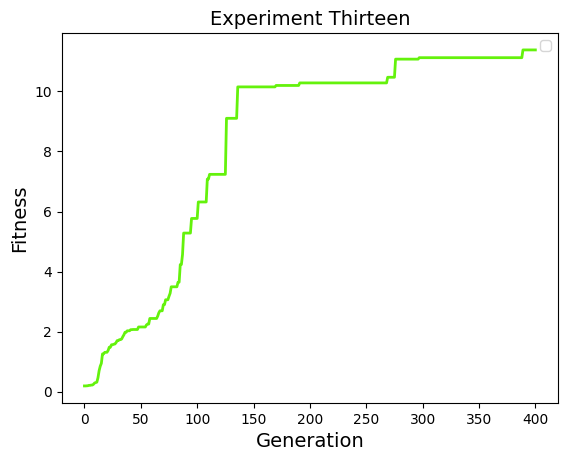

Figure(640x480)


In [15]:
print(ga_instance.plot_fitness(title=f"Experiment Thirteen", linewidth=2))

### - Run best solution

In [16]:
solution, solution_fitness, solution_index = ga_instance.best_solution()
predictions = pygad.kerasga.predict(model=prototype_model, solution=solution,data=data_inputs)
mae = keras.losses.MeanAbsoluteError()
absolute_error = mae(data_outputs, predictions).numpy()
print("Solution fitness: ", solution_fitness, " (20 is the best)")
print("Predictions: ", predictions)
print("Absolute Error: ", absolute_error)

Solution fitness:  11.382121  (20 is the best)
Predictions:  [[118.81537 ]
 [118.300064]
 [118.24715 ]
 ...
 [149.2991  ]
 [149.55212 ]
 [150.42921 ]]
Absolute Error:  1.7571417


### - Save Genetic Algorithm and export ML model

**Save Genetic Algorithm**

In [17]:
ga_instance.save(filename="genetic-algorithms/genetic_algorithm_experiment_thirteen")

**Export model (keras and tensorflow)**

In [18]:
# Get the best solution as a keras weight matrix
ga_best_solution_weights = pygad.kerasga.model_weights_as_matrix(model=prototype_model, weights_vector=solution)

# Set the weights
prototype_model.set_weights(ga_best_solution_weights)

In [19]:
# Save the model (for Keras)
prototype_model.save("models/experiment_thirteen_prototype_model.keras")

# Save the model (for Tensorflow)
prototype_model.export("models/experiment_thirteen_prototype_model_tf", format="tf_saved_model")

INFO:tensorflow:Assets written to: models/experiment_thirteen_prototype_model_tf/assets


INFO:tensorflow:Assets written to: models/experiment_thirteen_prototype_model_tf/assets


Saved artifact at 'models/experiment_thirteen_prototype_model_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5642297296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5642298256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5642297872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5642295568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5642299984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5642299600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5642300560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5642300368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5642300944: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Prediction using loaded model

### - Load model and make a prediction

Load the model

In [20]:
from keras.models import load_model

loaded_model = load_model("models/experiment_thirteen_prototype_model.keras")

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 11 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Make a prediction

In [21]:
keras_predictions_loaded_model = loaded_model.predict(data_inputs)
mae_loaded_model = keras.losses.MeanAbsoluteError()
absolute_error_loaded_model = mae(data_outputs, keras_predictions_loaded_model).numpy()
print("Predictions (loaded_model): ", keras_predictions_loaded_model)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model)

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step
Predictions (loaded_model):  [[118.81537 ]
 [118.300064]
 [118.24715 ]
 ...
 [149.2991  ]
 [149.55212 ]
 [150.42921 ]]
Absolute Error (loaded_model):  1.7571417


Same Absolute Error as the best solution of the Genetic Algorithm. This means that the model was saved correctly.

### - Test loaded model using test data

Using test_data check the MAE of the model. This data has not been used before, and thus works as a good way of measuring the performance of the model.

In [22]:
keras_predictions_loaded_model_with_test_data = loaded_model.predict(data_inputs_test)
absolute_error_loaded_model_with_test_data = mae(data_outputs_test, keras_predictions_loaded_model_with_test_data).numpy()
print("Predictions (loaded_model with test data): ", keras_predictions_loaded_model_with_test_data)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model_with_test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions (loaded_model with test data):  [[149.83582]
 [149.52505]
 [149.1334 ]
 [149.34103]
 [149.09409]
 [148.1885 ]
 [147.89267]
 [148.05669]
 [147.75403]
 [147.7373 ]
 [148.091  ]
 [148.49854]
 [148.04375]
 [148.13481]
 [147.68594]
 [147.17426]
 [147.11984]
 [146.6626 ]
 [146.88327]
 [147.16635]
 [146.96893]
 [147.38919]
 [147.71199]
 [147.80621]
 [147.6056 ]
 [147.55756]
 [147.80713]
 [148.51562]
 [148.23279]
 [148.49889]
 [148.77951]
 [148.25113]
 [148.22142]
 [148.0763 ]
 [147.58954]
 [146.09167]
 [146.39389]
 [146.83997]
 [146.15916]
 [146.62979]
 [145.13844]
 [144.33481]
 [143.8897 ]
 [143.93178]
 [143.07394]
 [143.3518 ]
 [143.23016]
 [142.39111]
 [143.30246]
 [143.79797]
 [143.62067]
 [144.14743]
 [143.31932]
 [143.29547]
 [143.69748]
 [145.1041 ]
 [145.13072]
 [144.44897]
 [143.58542]
 [144.22592]
 [145.53947]
 [145.4273 ]
 [147.02538]
 [146.80127]
 [146.33849]
 [145.70883]
 [145.60251]
 [145.1824 ]
 [144.90053]
 [144.38242]
 [144.513

Visualize predicted values

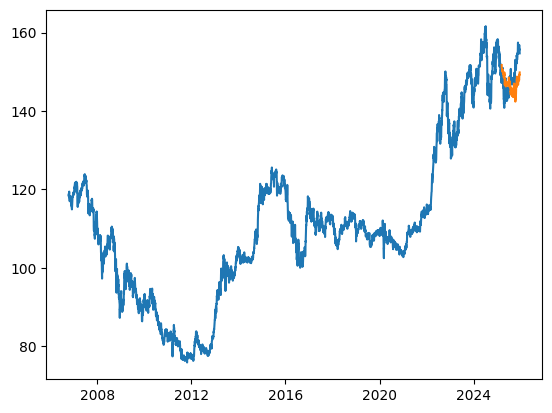

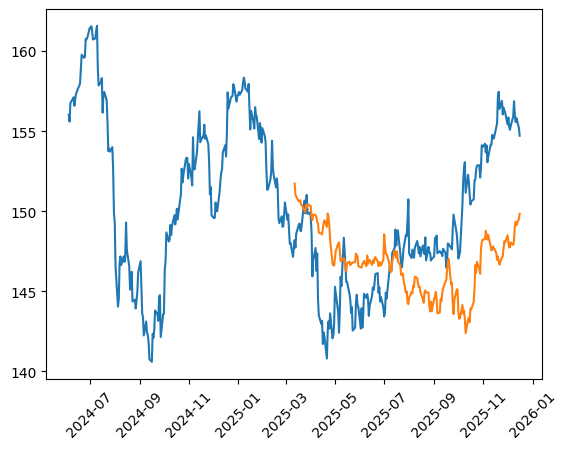

In [23]:
import matplotlib.pyplot as plt

# Flip data as it flips back again for some reason
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)

# Full data
plt.plot(usdYen_raw_data_dates, usdYen_raw_data)
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
plt.show()

# Zoom in on data
fig, ax = plt.subplots()
plt.plot(usdYen_raw_data_dates[:400], usdYen_raw_data[:400])
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
ax.tick_params("x", rotation=45)
plt.show()

## About the code

The Genetic Algorithm code is based on the code shown in the docs of the PyGAD library.

The timeseries data code is based on the code shown in the chapter of the book Deep Learning with Python.

## References

1- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries. Manning Publications.

2- PyGAD. pygad.kerasga Module. Retrieved from https://pygad.readthedocs.io/en/latest/kerasga.html#